# 9. Model Comparison and Final Model Selection

## Business Objective

Multiple machine learning algorithms were trained to predict customer churn.

The objective of this notebook is to compare their predictive performance and identify the model best suited for deployment.

The models evaluated are:

- Logistic Regression
- Decision Tree
- Tuned Decision Tree
- Random Forest
- Tuned Random Forest
- XGBoost

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
lr = pd.read_csv("../results/logistic_regression_results.csv")
dt = pd.read_csv("../results/decision_tree_results.csv")
dt_tuned = pd.read_csv("../results/tuned_decision_tree_results.csv")
rf = pd.read_csv("../results/random_forest_results.csv")
rf_tuned = pd.read_csv("../results/tuned_random_forest_results.csv")
xgb = pd.read_csv("../results/xgboost_results.csv")

In [3]:
model_results = pd.concat(
    [lr, dt, dt_tuned, rf, rf_tuned, xgb],
    ignore_index=True
)

model_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,LogisticRegression,0.803838,0.649390,0.569519,0.606838,0.836040
1,DecisionTreeClassifier,0.719261,0.471698,0.467914,0.469799,0.638830
2,DecisionTreeClassifier,0.778252,0.580729,0.596257,0.588391,0.819709
3,RandomForestClassifier,0.789623,0.625806,0.518717,0.567251,0.816300
4,RandomForestClassifier,0.795309,0.649306,0.500000,0.564955,0.838460
5,XGBClassifier,0.771144,0.576023,0.526738,0.550279,0.811390


In [4]:
model_results["Model"] = [
    "Logistic Regression",
    "Decision Tree",
    "Decision Tree (Tuned)",
    "Random Forest",
    "Random Forest (Tuned)",
    "XGBoost"
]

model_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.803838,0.649390,0.569519,0.606838,0.836040
1,Decision Tree,0.719261,0.471698,0.467914,0.469799,0.638830
2,Decision Tree (Tuned),0.778252,0.580729,0.596257,0.588391,0.819709
3,Random Forest,0.789623,0.625806,0.518717,0.567251,0.816300
4,Random Forest (Tuned),0.795309,0.649306,0.500000,0.564955,0.838460
5,XGBoost,0.771144,0.576023,0.526738,0.550279,0.811390


# Best Model Selection

To determine the best-performing model, the models are ranked based on their F1 Score. F1 Score is selected because it balances Precision and Recall, making it suitable for customer churn prediction where both false positives and false negatives are important.

In [5]:
model_results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.803838,0.649390,0.569519,0.606838,0.836040
2,Decision Tree (Tuned),0.778252,0.580729,0.596257,0.588391,0.819709
3,Random Forest,0.789623,0.625806,0.518717,0.567251,0.816300
4,Random Forest (Tuned),0.795309,0.649306,0.500000,0.564955,0.838460
5,XGBoost,0.771144,0.576023,0.526738,0.550279,0.811390
1,Decision Tree,0.719261,0.471698,0.467914,0.469799,0.638830


In [6]:
best_model = model_results.loc[
    model_results["F1 Score"].idxmax()
]

best_model

Model        Logistic Regression
Accuracy                0.803838
Precision                0.64939
Recall                  0.569519
F1 Score                0.606838
AUC                      0.83604
Name: 0, dtype: object

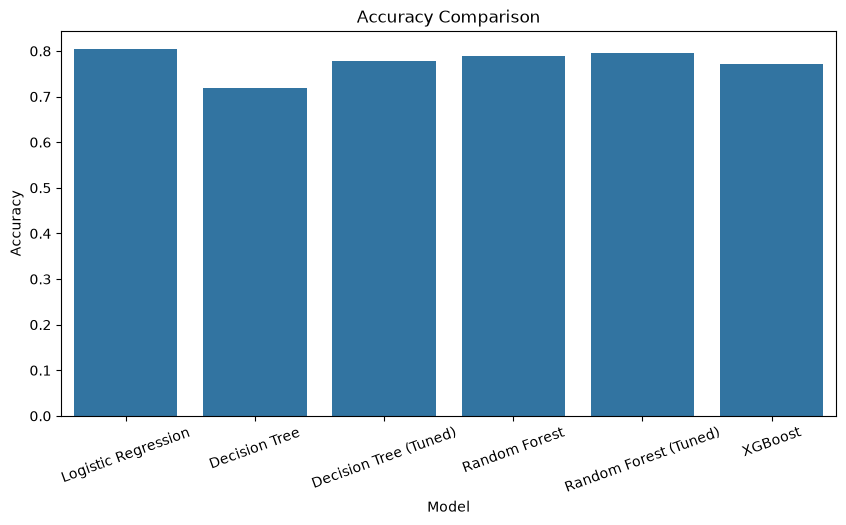

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison")
plt.xticks(rotation=20)

plt.savefig("../images/accuracy_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

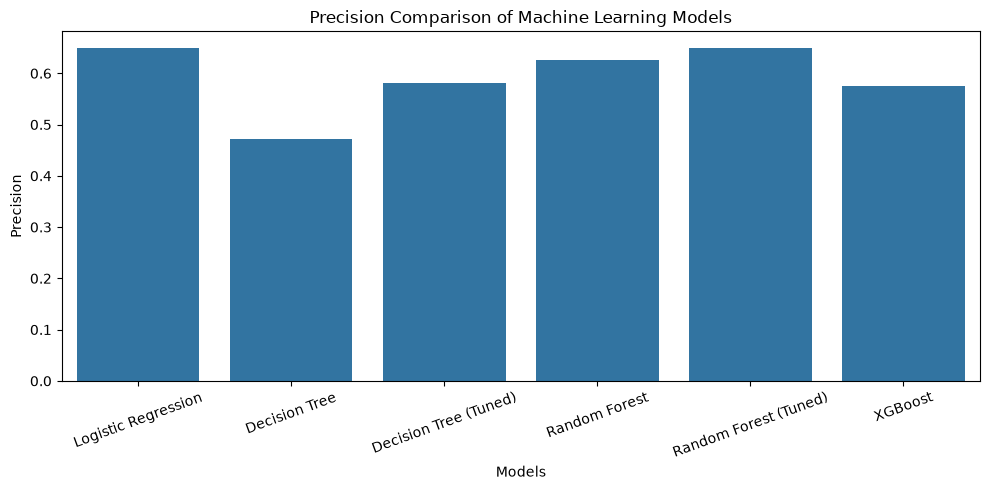

In [13]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=model_results,
    x="Model",
    y="Precision"
)

plt.title("Precision Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Precision")
plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../images/precision_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

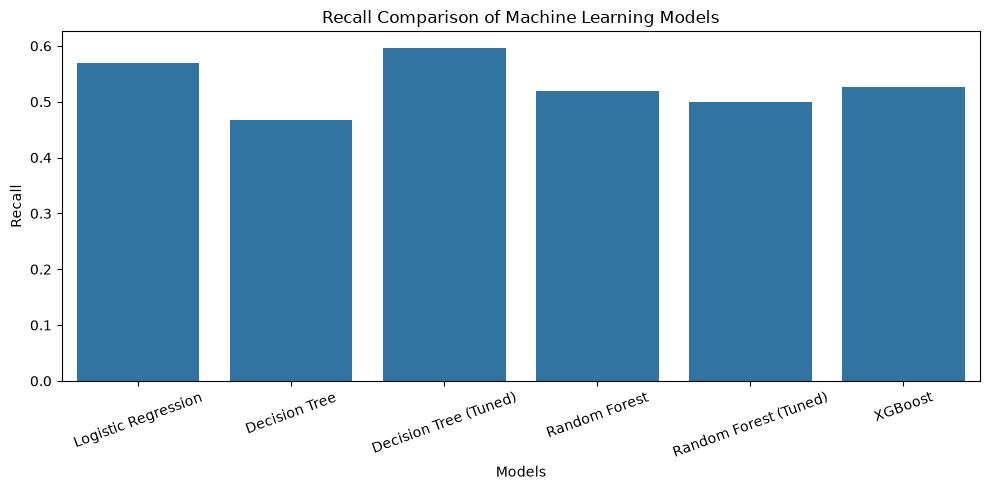

In [14]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=model_results,
    x="Model",
    y="Recall"
)

plt.title("Recall Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../images/recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

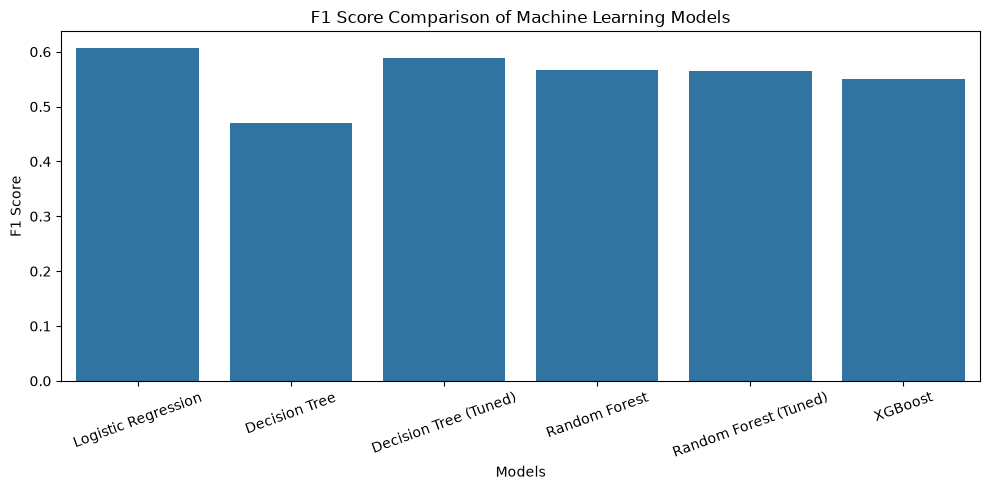

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=model_results,
    x="Model",
    y="F1 Score"
)

plt.title("F1 Score Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../images/f1_score_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

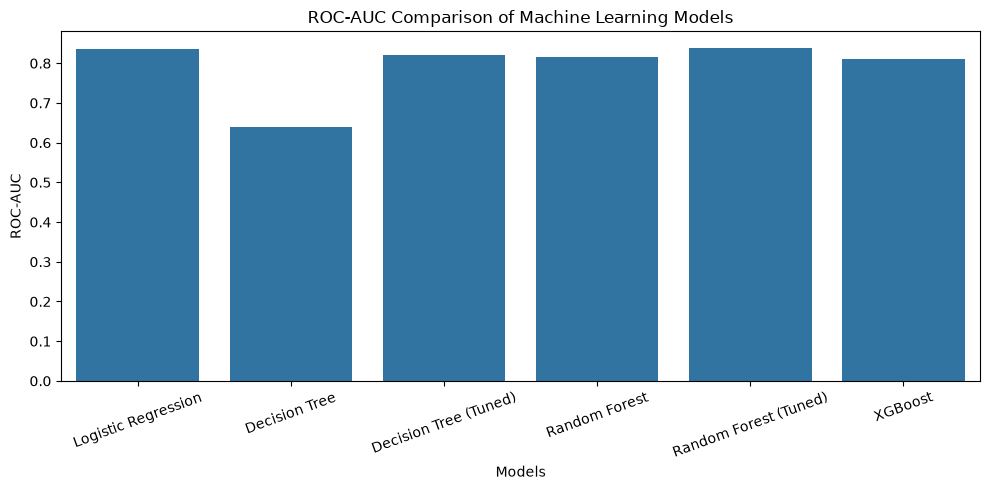

In [16]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=model_results,
    x="Model",
    y="AUC"
)

plt.title("ROC-AUC Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../images/auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Best Model Selection

To determine the most suitable model for customer churn prediction, all trained models were compared using the following evaluation metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Since the dataset is moderately imbalanced, the **F1 Score** was selected as the primary evaluation metric because it provides a balanced measure of Precision and Recall.

In [17]:
best_model = model_results.loc[
    model_results["F1 Score"].idxmax()
]

print("Best Performing Model")
best_model

Best Performing Model


Model        Logistic Regression
Accuracy                0.803838
Precision                0.64939
Recall                  0.569519
F1 Score                0.606838
AUC                      0.83604
Name: 0, dtype: object

# Final Business Conclusion

Six machine learning models were trained and evaluated for predicting customer churn.

Among the evaluated models, **Logistic Regression** achieved the highest F1 Score while maintaining strong Accuracy, Precision, Recall, and ROC-AUC performance.

Although the Tuned Random Forest achieved a slightly higher ROC-AUC score, Logistic Regression provided a better overall balance between identifying churning customers and minimizing false predictions.

Therefore, Logistic Regression was selected as the final production model.

### Key Business Insights

The analysis identified several factors that strongly influence customer churn:

- Customers with month-to-month contracts are more likely to churn.
- Customers with shorter tenure have a higher probability of leaving.
- Higher monthly charges are associated with increased churn.
- Customers without Online Security or Tech Support are more likely to discontinue the service.

### Business Recommendations

- Encourage customers to move from month-to-month contracts to longer-term plans.
- Improve customer engagement during the first few months of service.
- Offer bundled services such as Online Security and Tech Support.
- Design retention campaigns targeting customers with high monthly charges and short tenure.